In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA 

In [2]:
df = pd.read_csv("data/train.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


In [40]:
missing = df.isna().sum().to_frame("missing_count")
missing["missing_percent"] = missing["missing_count"] / len(df) * 100
missing

,missing_count,missing_percent
vendor_id,0,0.0
pickup_datetime,0,0.0
dropoff_datetime,0,0.0
passenger_count,0,0.0
pickup_longitude,0,0.0
pickup_latitude,0,0.0
dropoff_longitude,0,0.0
dropoff_latitude,0,0.0
store_and_fwd_flag,0,0.0
trip_duration,0,0.0


There are no missing values in the dataset, so imputation is not required. Therefore, the main data-quality concerns are not missingness but invalid values, outliers, unrealistic coordinates, and impossible trip speeds.

In [ ]:
df.drop(columns=["id","dropoff_datetime"],inplace=True) #dropping id column since it is irrelvant for the analysis and prediction

We also remove the dropoff datetime as it is post-trip information and cause data leakage because it is only known after a trip and directly tells us the duration (along with pickup time)

In [4]:
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


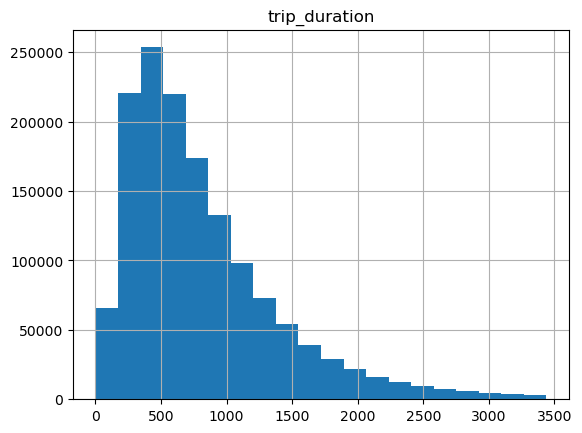

In [15]:
threshold = 0.99
trip_duration_threshold = df["trip_duration"].quantile(threshold)
filtered_threshold = df[df["trip_duration"] < trip_duration_threshold]
filtered_threshold.hist("trip_duration",bins=20)
plt.show()

histogram shows that the majority of trips around around 500 seconds and that there is a long tail since the duration is right skewed. We filter the trip duration to the 99th percentile to avoid extreme outliers distorting the plots.

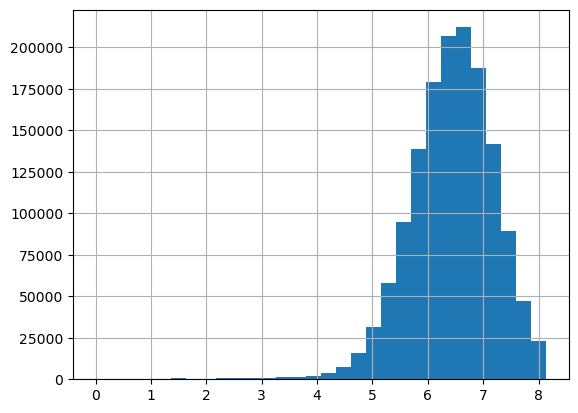

In [ ]:
log_trip_duration = np.log(filtered_threshold["trip_duration"])
log_trip_duration.hist(bins=30)
plt.show()

Logging the trip duration and plotting the distribution makes it more bell shaped by reducing the skew. This will help when modelling by helping prevent heteroscedasticity and remove the effect of extreme outliers

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


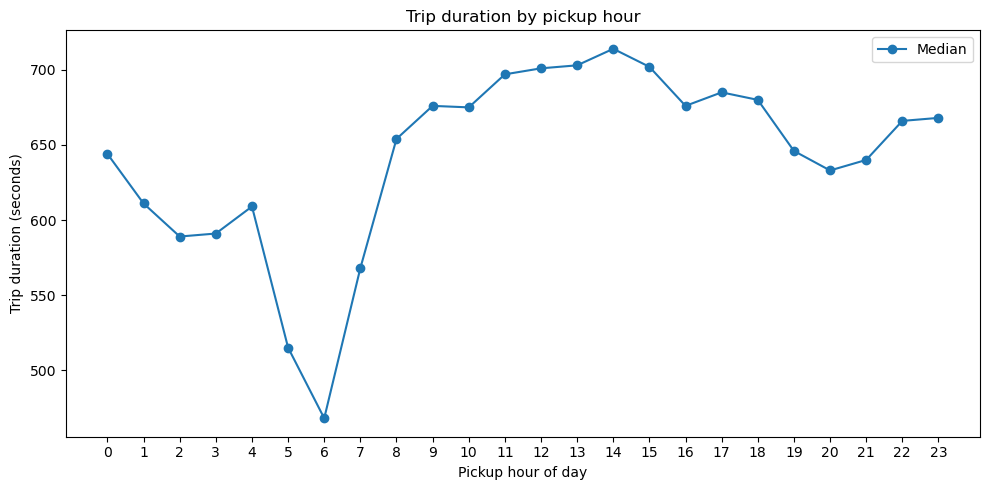

In [26]:
plot_df = filtered_threshold.copy()
plot_df["pickup_datetime"] = pd.to_datetime(plot_df["pickup_datetime"])
plot_df["pickup_hour"] = plot_df["pickup_datetime"].dt.hour

duration_by_hour = plot_df.groupby("pickup_hour")["trip_duration"].agg(["median", "mean"])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(duration_by_hour.index, duration_by_hour["median"], marker="o", label="Median")
ax.set_xlabel("Pickup hour of day")
ax.set_ylabel("Trip duration (seconds)")
ax.set_title("Trip duration by pickup hour")
ax.set_xticks(range(24))
ax.legend()
plt.tight_layout()
plt.show()

Given that the data is skewed we plot the median trip duration per hour. The results show that the longest trips are from 11am to 3pm and the shortest between 5am and 7am.

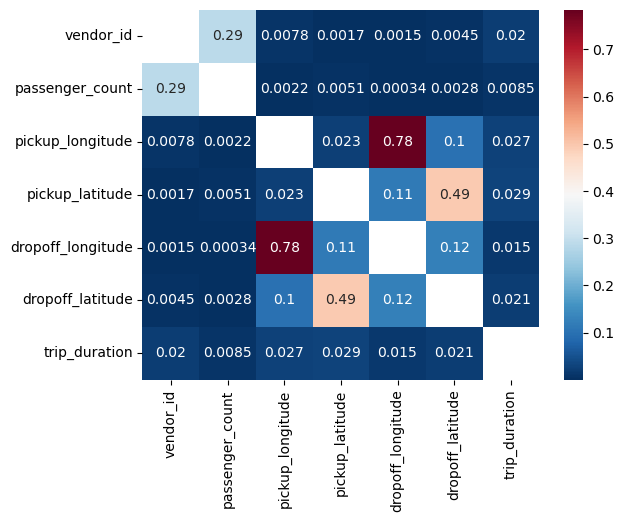

In [39]:
corr_matrix = df.select_dtypes(include=[np.number]).corr().abs()
mask = np.eye(len(corr_matrix), dtype=bool)
sns.heatmap(corr_matrix, annot=True, cmap="RdBu_r", mask=mask)
plt.show()


For the heatmap we omitted the middle diagonal to make the correlation between variables for apparent. The results show that pickup latitue/longititude have the highest correlation with trip duration

### How well does distance correlate with trip duration

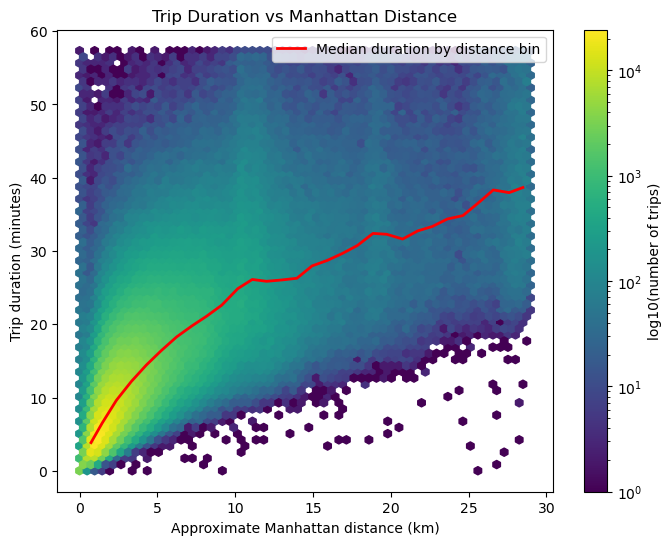

In [56]:
lat_km = 111
lon_km = 85  # longitude degree is about 85 km around NYC latitude

df["manhattan_km"] = (
    np.abs(df["dropoff_latitude"] - df["pickup_latitude"]) * lat_km
    + np.abs(df["dropoff_longitude"] - df["pickup_longitude"]) * lon_km
)
plot_df = df[
    (df["manhattan_km"] > 0) &
    (df["manhattan_km"] <= df["manhattan_km"].quantile(0.99)) &
    (df["trip_duration"] > 0) &
    (df["trip_duration"] <= df["trip_duration"].quantile(0.99))
].copy()

plot_df["trip_duration_min"] = plot_df["trip_duration"] / 60

plot_df["distance_bin"] = pd.cut(plot_df["manhattan_km"], bins=30)

trend = (
    plot_df.groupby("distance_bin", observed=True)
    .agg(
        median_distance=("manhattan_km", "median"),
        median_duration=("trip_duration_min", "median")
    )
    .dropna()
)

plt.figure(figsize=(8, 6))
hb = plt.hexbin(
    plot_df["manhattan_km"],
    plot_df["trip_duration_min"],
    gridsize=60,
    bins="log",
    mincnt=1
)

plt.plot(
    trend["median_distance"],
    trend["median_duration"],
    linewidth=2,
    label="Median duration by distance bin",
    color="red"
)

plt.xlabel("Approximate Manhattan distance (km)")
plt.ylabel("Trip duration (minutes)")
plt.title("Trip Duration vs Manhattan Distance")
plt.colorbar(hb, label="log10(number of trips)")
plt.legend()
plt.show()

Trip duration generally increases with Manhattan distance, but there is large vertical spread at each distance, suggesting that distance alone is not sufficient. This motivates adding temporal and spatial features such as pickup hour, day of week, and pickup/dropoff coordinates.

In [57]:
df["trip_duration"].describe()

count    1.458644e+06
mean     9.594923e+02
std      5.237432e+03
min      1.000000e+00
25%      3.970000e+02
50%      6.620000e+02
75%      1.075000e+03
max      3.526282e+06
Name: trip_duration, dtype: float64